In [11]:
%reset -f -s
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import pandas as pd
from bspline_model import *
from workout import *
from dashboard import create_date_selector_dashboard




workout_df = pd.DataFrame([
    ('polar_data/oo_dd_2025-12-24_18-32-17.CSV', standard_3x4.name, 130, 0),
    ('polar_data/oo_dd_2025-12-30_11-32-46.CSV', standard_3x4.name, 240, 0),
    ('polar_data/oo_dd_2026-01-02_17-45-25.CSV', standard_3x4.name, 240, 0),
    ('polar_data/oo_dd_2026-01-05_16-54-37.CSV', standard_3x4.name, 240, 0),
    ('polar_data/oo_dd_2026-01-07_17-13-36.CSV', standard_3x4.name, 240, 0), 
    ('polar_data/oo_dd_2026-01-15_16-59-15.CSV', xtrainer_4x4.name, 0, 0),
    ('polar_data/oo_dd_2026-01-18_16-31-02.CSV', standard_3x4.name, 240, 0),
    ('polar_data/oo_dd_2026-01-29_17-17-32.CSV', standard_3x4.name, 240, 0),
    ('polar_data/oo_dd_2026-02-03_17-40-57.CSV', standard_3x4.name, 240, 0),
    ('polar_data/oo_dd_2026-02-11_17-17-27.CSV', standard_3x4.name, 240, 0),
    ('polar_data/oo_dd_2026-02-13_17-05-31.CSV', l2h2_4x4.name, 0, 0),
    ('polar_data/oo_dd_2026-03-16_16-56-12.CSV', l2h2_4x4.name, 0, 0)
    ],
    columns=["file_path", "workout_config", "n_drop", "kernel_size"]).assign(
        session_name=lambda x: [Path(p).stem[6:16] for p in x.file_path],
        cache_path=lambda x: [Path(p).with_suffix(".nc") for p in x.file_path]
    )

knots_data = {
    "2025-12-24": np.array(list(sorted(
        set(range(0, 841, 40)) | {152, 162, 200, 210, 240, 256, 388, 660, 720}
        ))).reshape((-1, 1)),
    "2025-12-30": np.array(list(sorted(
        set(range(0, 854, 30)) | {126, 145, 700, 734, 747}
    ))).reshape((-1, 1)),
    "2026-01-02": np.array(list(sorted(
        set(range(0, 847, 40)) | {222, 242, 420, 440, 485, 527, 698, 726}
    ))).reshape((-1, 1)),
    "2026-01-05": np.array(list(sorted(
        set(range(0, 848, 40)) | {210, 225, 260, 419, 454, 505, 560, 616, 700, 731}
    ))).reshape((-1, 1)),
    "2026-01-07": np.array(list(sorted(
        set(range(0, 848, 40)) | {210, 225, 260, 419, 454, 505, 560, 700, 731}
    ))).reshape((-1, 1)),
    "2026-01-15": np.array(list(sorted(
        set(range(0, 848, 40)) | {40}
    ))).reshape((-1, 1)),
    "2026-01-18": np.array(list(sorted(
        set(range(0, 866, 40)) | {210, 225, 250, 260, 470, 455, 490, 505, 560, 700, 727, 740}
    ))).reshape((-1, 1)),
    "2026-01-29": np.array(list(sorted(
        set(range(0, 850, 40)) | {60, 450, 547, 700, 786}
    ))).reshape((-1, 1)),
    "2026-02-03": np.array(list(sorted(
        (set(range(0, 850, 40)) - {640}) | {290}
    ))).reshape((-1, 1)),
    "2026-02-11": np.array(list(sorted(
        (set(range(0, 850, 40))) | {223, 295, 456, 671, 743, 494, 729}
    ))).reshape((-1, 1)),
    "2026-02-13": np.array(list(sorted(
        (set(range(0, 1087, 40))) | {265, 270, 490, 530, 730, 745, 973, 980}
    ))).reshape((-1, 1)),
    "2026-03-16": np.array(list(sorted(
        (set(range(0, 1136, 40))) | {250, 255, 270, 487, 490, 850, 875, 970, 980}
    ))).reshape((-1, 1)),
    
}

wc = l2h2_4x4
load_cache = True
sessions = []
for i, session_row in list(workout_df.iterrows()):
    
    # if session_row.session_name != "2026-03-16":
    #     continue
    
    session_df = pd.read_csv(session_row.file_path, skiprows=2).iloc[session_row.n_drop:, 1:3].assign(
        time_sec=lambda x: pd.to_timedelta(x.Time).dt.total_seconds() - session_row.n_drop
    )
    # print(session_row.session_name)
    # print(session_df.time_sec.shape[0])
    bsm = BsplineModel(knots=knots_data[session_row.session_name], time_sec=session_df.time_sec.values, hr=session_df['HR (bpm)'].values, 
                       load_cache=load_cache, cache_path=session_row.cache_path)
    analytics = TreadmillAnalytic(model=bsm, session_id=f"{session_row.session_name}", config=wc)
    sessions.append(analytics)

report = TreadmillReport(wc, sessions)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:

create_date_selector_dashboard(report.sessions).show()



In [13]:
report.sessions[-1].session_id

'2026-03-16'

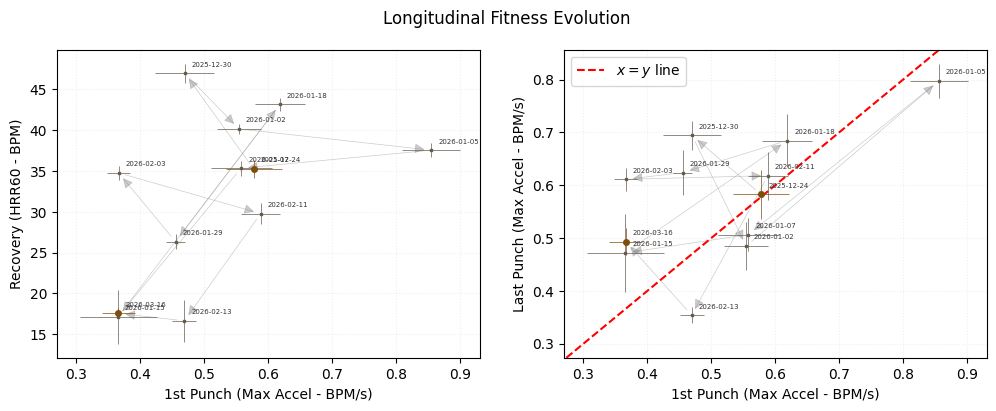

In [14]:
# report = TreadmillReport(standard_3x4, file_paths, False)
fig, ax_quad = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=False)
report.plot_trend_vector(fig, ax_quad[0], 'ph')
report.plot_trend_vector(fig, ax_quad[1], 'pp')
ax_quad[1].axline((0.3, 0.3), slope=1, color='r', linestyle='--', label='$x=y$ line'); ax_quad[1].legend()


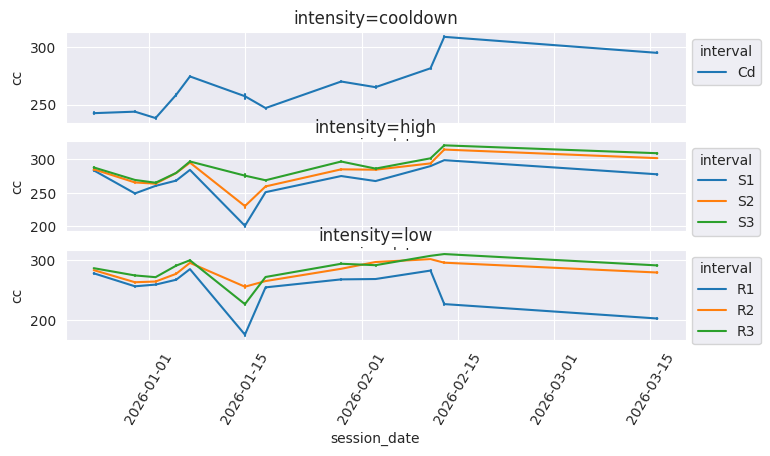

In [15]:
with sns.axes_style("darkgrid"):
    report.plot_cardiac_cost()